In [3]:
import pandas as pd
import numpy as np

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [7]:
df = pd.read_excel(r"H:\FOM- Study Material\Semester Three\Big-Data-Consulting Project\Project\Storck dataset.xlsx", sheet_name = 0)

In [8]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(150, 22)

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)

In [14]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Feature Engineering

In [17]:

# 1. Discount_Impact (€) = Revenue_Before_Promo - Revenue_During_Promo
df["Discount_Impact (€)"] = df["Revenue_Before_Promo (€)"] - df["Revenue_During_Promo (€)"]

In [19]:
# 2. Margin_% = Gross_Margin (€) / Revenue_During_Promo (€)
df["Margin_%"] = np.where(df["Revenue_During_Promo (€)"] > 0,
                          df["Gross_Margin (€)"] / df["Revenue_During_Promo (€)"] * 100, 0)

In [21]:
# 3. Promo_Efficiency_Score = ROI (%) * Margin_% / 100 (normalized)
df["Promo_Efficiency_Score"] = (df["ROI (%)"] * df["Margin_%"]) / 100

In [23]:
# Optional: Cap outliers in ROI and Margin_% to improve downstream modeling
df["ROI (%)"] = np.clip(df["ROI (%)"], -100, 100)
df["Margin_%"] = np.clip(df["Margin_%"], 0, 100)

In [25]:
# ------------------- Save Cleaned Data -------------------
df.to_excel("Storck_Phase1_Cleaned.xlsx", index=False)

# EDA

In [28]:
# Dataset summary
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Product_ID,150.0,15.5,1.0,8.0,15.5,23.0,30.0,8.684438
Promotion_Start_Date,150,2024-07-02 22:33:36,2024-01-05 00:00:00,2024-03-23 06:00:00,2024-07-12 00:00:00,2024-10-02 06:00:00,2024-12-25 00:00:00,NaN
Promotion_End_Date,150,2024-07-14 18:33:36,2024-01-04 00:00:00,2024-04-03 12:00:00,2024-07-23 00:00:00,2024-10-10 06:00:00,2025-01-01 00:00:00,NaN
Promo_Duration_Days,150.0,17.713333,7.0,14.0,14.0,20.5,60.0,9.430307
Base_Units_Sold,150.0,86.72,19.0,40.0,65.5,106.0,628.0,80.095423
Units_Sold_Before_Promo,150.0,90.0,18.0,40.0,65.5,112.0,745.0,90.449363
Units_Sold_During_Promo,150.0,104.573333,21.0,52.25,80.5,128.5,745.0,93.216307
Unit_Cost_Before_Promo (€),150.0,2.1,0.52,1.19,1.69,2.54,6.88,1.412017
Unit_Price (€),150.0,3.734333,0.89,2.24,3.055,4.43,11.46,2.42182
COGS_Ratio,150.0,0.559333,0.5,0.54,0.56,0.58,0.6,0.027531


In [30]:
# Check for missing values
df.isnull().sum()


Product_ID                    0
Product_Name                  0
Category                      0
Channel                       0
Promotion_Type                0
Promotion_Start_Date          0
Promotion_End_Date            0
Promo_Duration_Days           0
Base_Units_Sold               0
Units_Sold_Before_Promo       0
Units_Sold_During_Promo       0
Unit_Cost_Before_Promo (€)    0
Unit_Price (€)                0
COGS_Ratio                    0
Revenue_Before_Promo (€)      0
Revenue_During_Promo (€)      0
Total_COGS (€)                0
Promo_Cost (€)                0
Gross_Margin (€)              0
ROI (%)                       0
ROI_Bracket                   0
Trend_Tag                     0
Discount_Impact (€)           0
Margin_%                      0
Promo_Efficiency_Score        0
dtype: int64

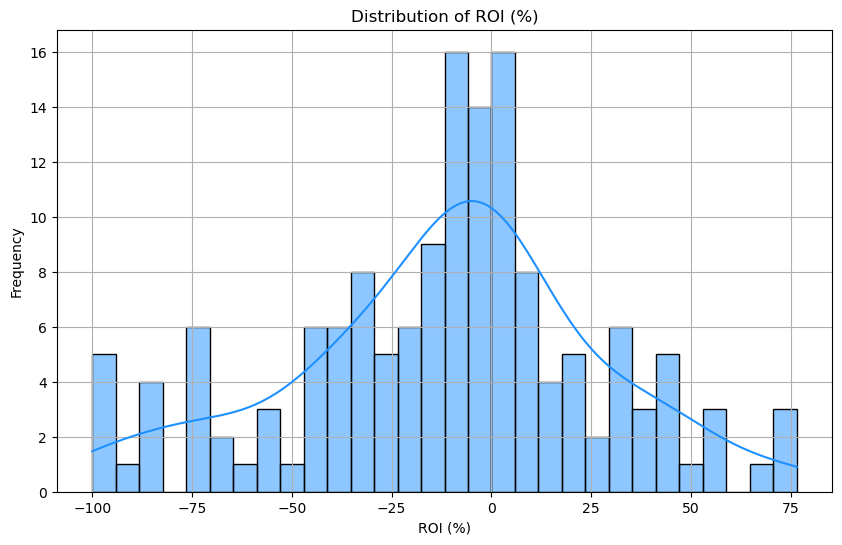

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['ROI (%)'], kde=True, bins=30, color='dodgerblue')
plt.title("Distribution of ROI (%)")
plt.xlabel("ROI (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


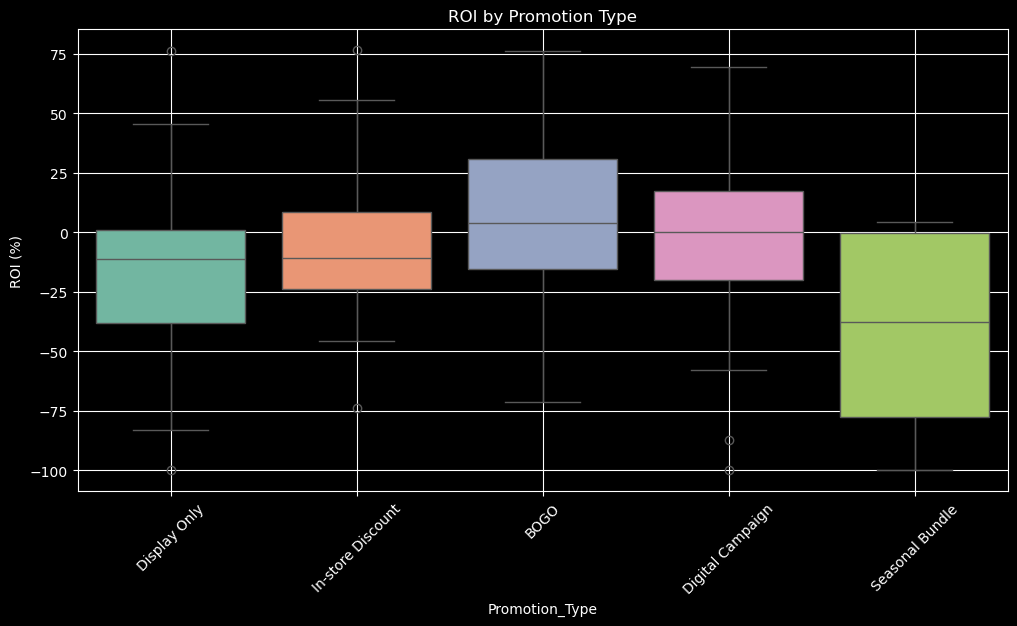

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Promotion_Type', y='ROI (%)', hue='Promotion_Type', palette='Set2', legend=False)
plt.title("ROI by Promotion Type")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


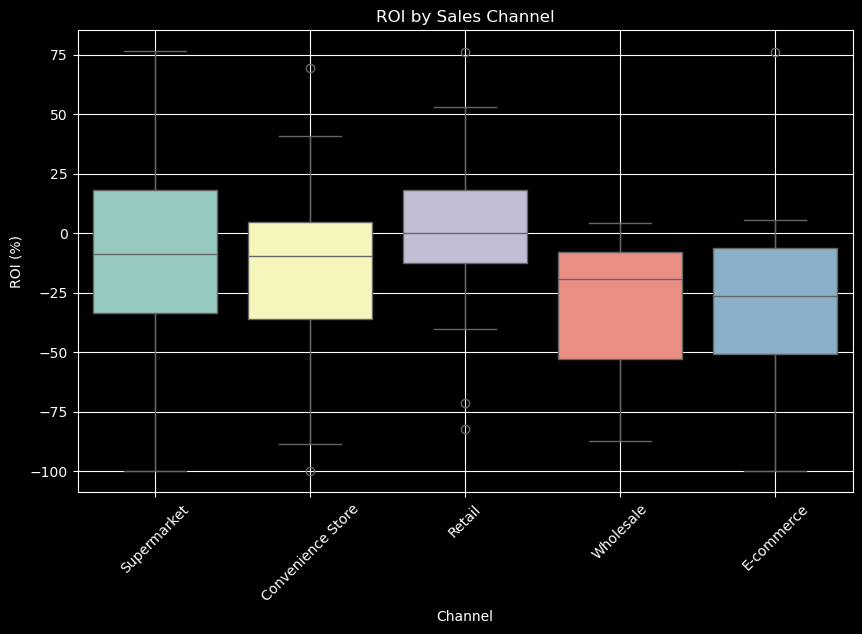

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Channel', y='ROI (%)', hue='Channel', palette='Set3', legend=False)
plt.title("ROI by Sales Channel")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


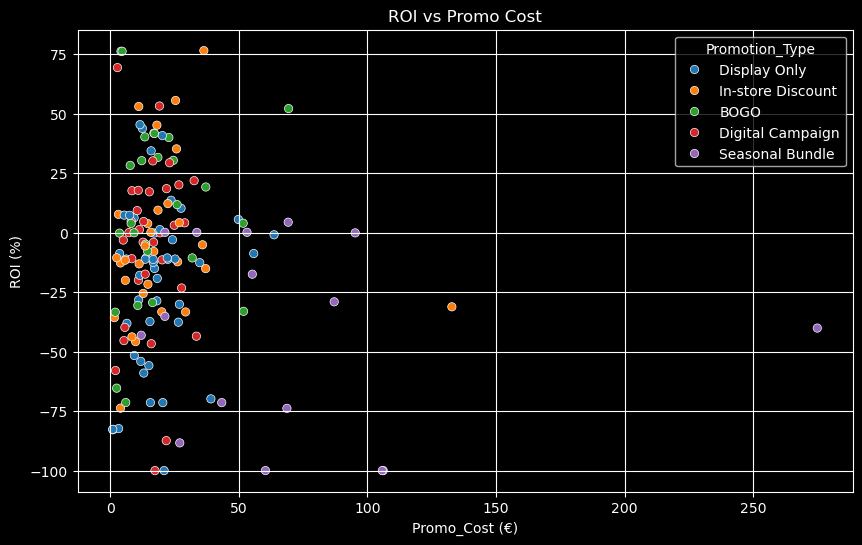

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Promo_Cost (€)', y='ROI (%)', hue='Promotion_Type', palette='tab10')
plt.title("ROI vs Promo Cost")
plt.grid(True)
plt.show()


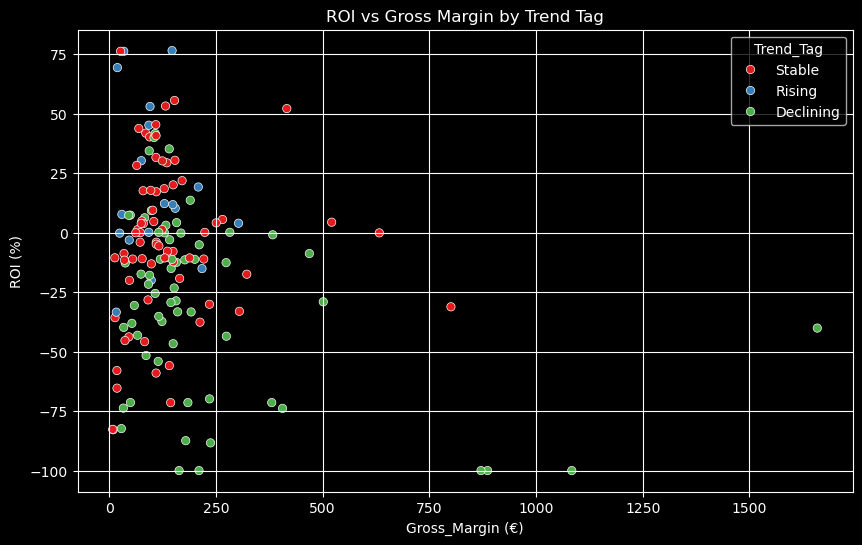

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Gross_Margin (€)', y='ROI (%)', hue='Trend_Tag', palette='Set1')
plt.title("ROI vs Gross Margin by Trend Tag")
plt.grid(True)
plt.show()


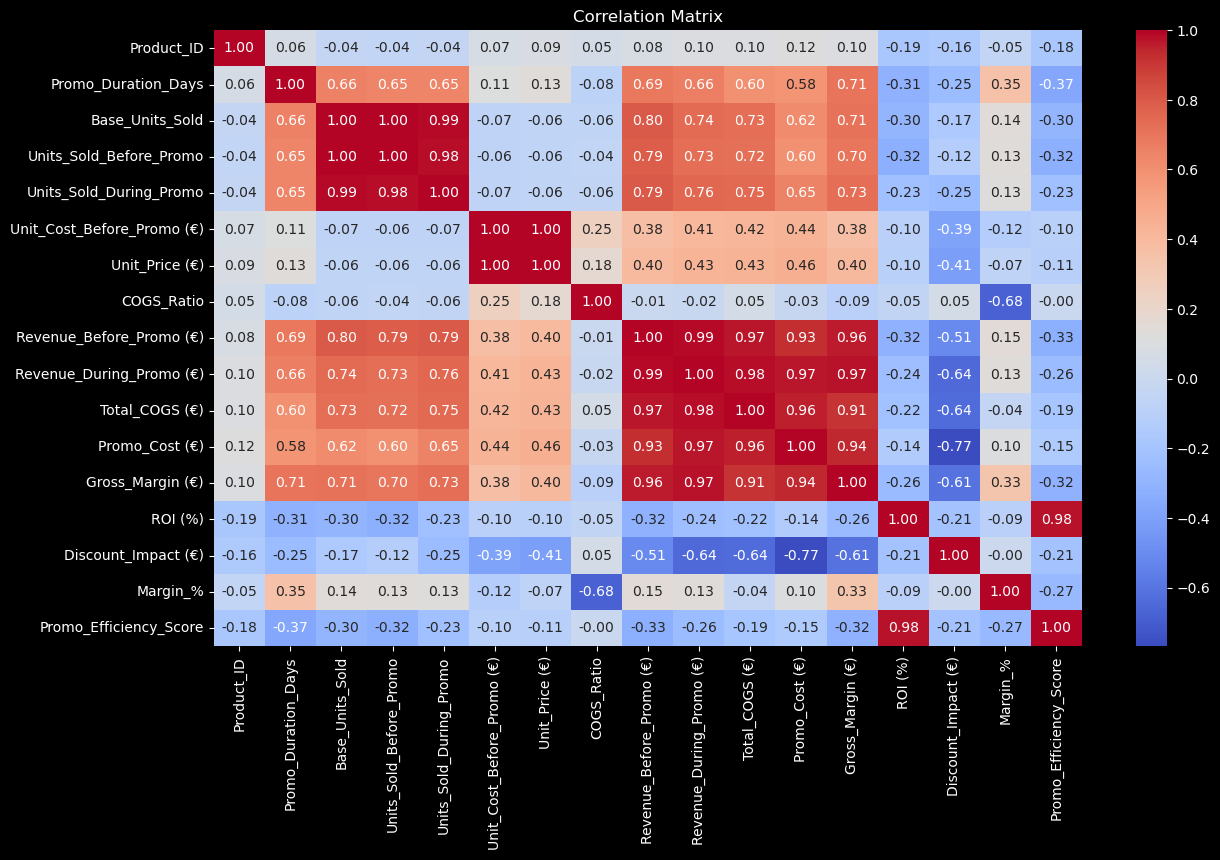

In [46]:
plt.figure(figsize=(14, 8))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


## Clustering

In [48]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [50]:
# Load the Cleaned Dataset
df = pd.read_excel("Storck_Phase1_Cleaned.xlsx")

In [52]:
# Select Features for Clustering
features = [
    "ROI (%)", 
    "Promo_Efficiency_Score", 
    "Margin_%", 
    "Promo_Duration_Days", 
    "Units_Sold_During_Promo", 
    "Promo_Cost (€)"
]
X = df[features].copy()

# Normalize the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

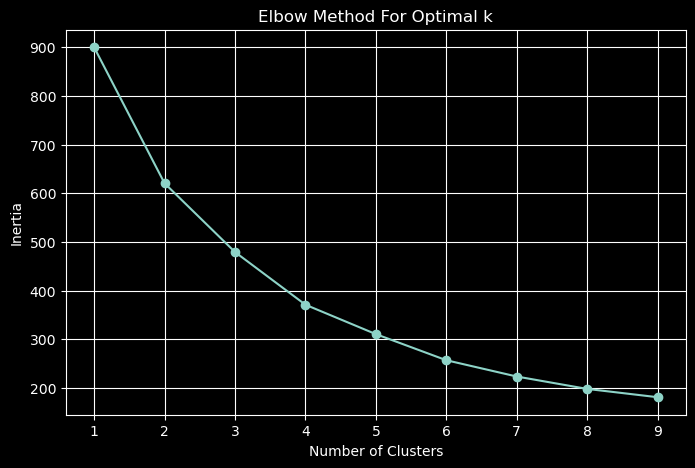

In [54]:
# Elbow Method to Determine Optimal Clusters
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")
plt.grid(True)
plt.show()


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


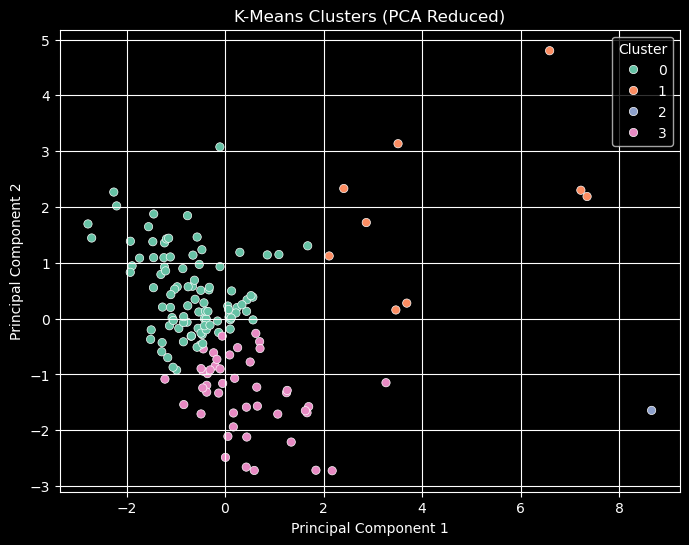

In [56]:
# Apply K-Means with chosen number of clusters (k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualize the Clusters with PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df["PC1"] = components[:, 0]
df["PC2"] = components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set2")
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


In [58]:
# Cluster-level summary statistics
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)[[
    "ROI (%)", "Promo_Efficiency_Score", "Total_COGS (€)",
    "Gross_Margin (€)", "Revenue_During_Promo (€)", "Margin_%"
]].round(2)

# Show the number of promotions per cluster
cluster_counts = df["Cluster"].value_counts().sort_index()
# Combine both into one summary table
cluster_summary["Num_Promotions"] = cluster_counts
display(cluster_summary)


,ROI (%),Promo_Efficiency_Score,Total_COGS (€),Gross_Margin (€),Revenue_During_Promo (€),Margin_%,Num_Promotions
Cluster,,,,,,,
0,10.79,4.72,167.84,132.73,300.57,44.40,95
1,-49.04,-20.82,929.84,740.00,1669.84,44.48,9
2,-100.00,-89.73,123.99,1083.84,1207.83,89.73,1
3,-49.47,-21.53,148.07,114.13,262.20,43.17,45


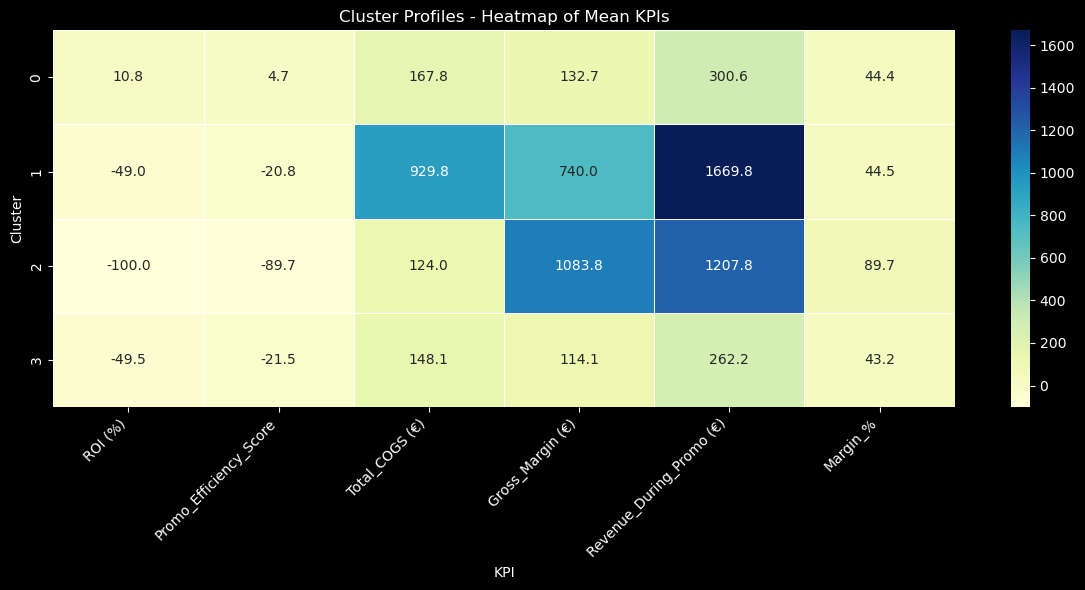

In [60]:
# Drop count column for heatmap (since it's categorical)
heatmap_data = cluster_summary.drop(columns=["Num_Promotions"])

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Cluster Profiles - Heatmap of Mean KPIs")
plt.xlabel("KPI")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [62]:
# Automatically describe cluster characteristics
for i in range(cluster_summary.shape[0]):
    print(f"\n Cluster {i} — Profile:")
    print(f"- Avg ROI: {cluster_summary.loc[i, 'ROI (%)']}%")
    print(f"- Promo Efficiency Score: {cluster_summary.loc[i, 'Promo_Efficiency_Score']}")
    print(f"- Margin: {cluster_summary.loc[i, 'Margin_%']}%")
    print(f"- Revenue During Promo: €{cluster_summary.loc[i, 'Revenue_During_Promo (€)']}")
    print(f"- Promotions in this group: {int(cluster_summary.loc[i, 'Num_Promotions'])}")



 Cluster 0 — Profile:
- Avg ROI: 10.79%
- Promo Efficiency Score: 4.72
- Margin: 44.4%
- Revenue During Promo: €300.57
- Promotions in this group: 95

 Cluster 1 — Profile:
- Avg ROI: -49.04%
- Promo Efficiency Score: -20.82
- Margin: 44.48%
- Revenue During Promo: €1669.84
- Promotions in this group: 9

 Cluster 2 — Profile:
- Avg ROI: -100.0%
- Promo Efficiency Score: -89.73
- Margin: 89.73%
- Revenue During Promo: €1207.83
- Promotions in this group: 1

 Cluster 3 — Profile:
- Avg ROI: -49.47%
- Promo Efficiency Score: -21.53
- Margin: 43.17%
- Revenue During Promo: €262.2
- Promotions in this group: 45


 ## Classification: Predict ROI_Bracket

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Encode target variable
df['ROI_Bracket_encoded'] = LabelEncoder().fit_transform(df['ROI_Bracket'])

# Select features and target
X_cls = df.drop(columns=['ROI_Bracket', 'ROI_Bracket_encoded', 'Cluster', 'PC1', 'PC2', 'Product_Name', 'Promotion_Start_Date', 'Promotion_End_Date'])
X_cls = pd.get_dummies(X_cls, drop_first=True)  # Handle categorical
y_cls = df['ROI_Bracket_encoded']

# Split
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Train model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict & evaluate
y_pred = clf.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[15  0  0]
 [ 1  2  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           1       0.94      1.00      0.97        15
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00        12

    accuracy                           0.97        30
   macro avg       0.98      0.89      0.92        30
weighted avg       0.97      0.97      0.96        30



 ## Regression: Predict ROI (%) or Promo_Efficiency_Score

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Target and features
target = 'ROI (%)'  # or 'Promo_Efficiency_Score'
X_reg = df.drop(columns=[target, 'Cluster', 'PC1', 'PC2', 'ROI_Bracket', 'Product_Name', 'Promotion_Start_Date', 'Promotion_End_Date'])
X_reg = pd.get_dummies(X_reg, drop_first=True)
y_reg = df[target]

In [70]:
# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_r, y_train_r)

RandomForestRegressor(random_state=42)

In [72]:
# Predict & evaluate
y_pred_r = reg.predict(X_test_r)
print("RMSE:", mean_squared_error(y_test_r, y_pred_r, squared=False))
print("R² Score:", r2_score(y_test_r, y_pred_r))

RMSE: 3.0881600954829564
R² Score: 0.9895320143504451


## Plot: Actual vs Predicted ROI

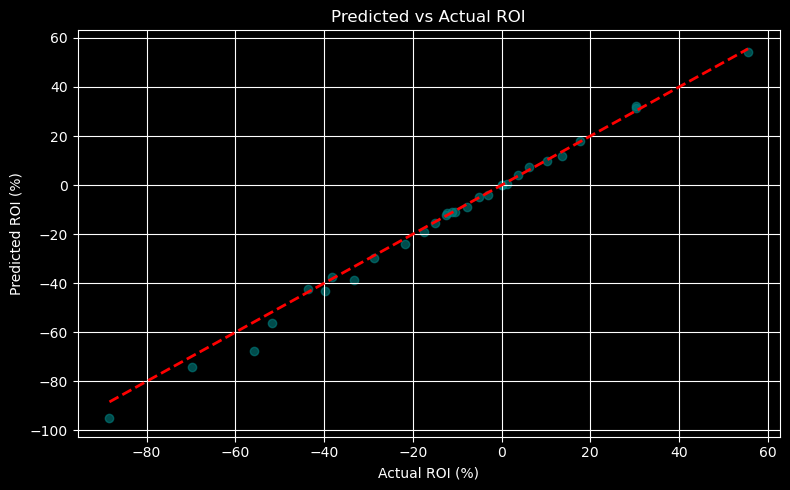

In [75]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, y_pred_r, color='teal', alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel("Actual ROI (%)")
plt.ylabel("Predicted ROI (%)")
plt.title("Predicted vs Actual ROI")
plt.grid(True)
plt.tight_layout()
plt.show()

In [77]:
comparison_df = pd.DataFrame({
    "Actual ROI (%)": y_test_r.values,
    "Predicted ROI (%)": y_pred_r
}).reset_index(drop=True)

comparison_df.head(10)


,Actual ROI (%),Predicted ROI (%)
0,13.60,11.8415
1,-10.51,-10.7937
2,-88.36,-95.0287
3,0.10,0.0480
4,-38.13,-37.4356
5,-15.06,-15.2736
6,-33.33,-38.7599
7,-5.11,-5.0523
8,0.14,-0.0971
9,-39.82,-43.2760


## Residual Error Plot

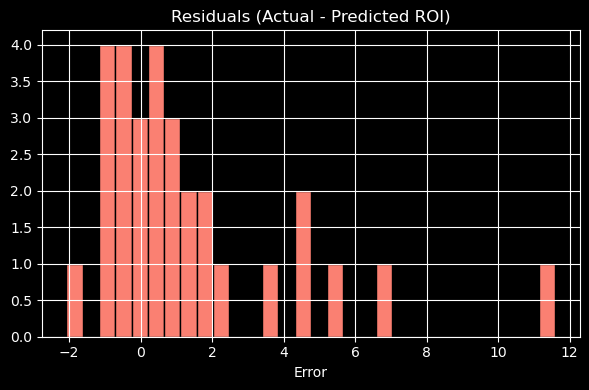

In [80]:
residuals = y_test_r - y_pred_r
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color='salmon', edgecolor='black')
plt.title("Residuals (Actual - Predicted ROI)")
plt.xlabel("Error")
plt.grid(True)
plt.tight_layout()
plt.show()


##  Classification – Predict ROI Category (e.g. High vs Low ROI)

In [89]:
# Create binary label: 1 = Good ROI, 0 = Bad ROI
df['ROI_Binary'] = df['ROI (%)'].apply(lambda x: 1 if x > 0 else 0)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [91]:
#Drop unused or non-numeric columns
X_cls = df.drop(columns=['ROI (%)', 'ROI_Bracket', 'PC1', 'PC2', 'Cluster', 'Product_Name', 'Promotion_Start_Date', 'Promotion_End_Date', 'ROI_Binary'])
X_cls = pd.get_dummies(X_cls, drop_first=True)

y_cls = df['ROI_Binary']

In [93]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)
import joblib


In [95]:
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Accuracy: 1.0

Confusion Matrix:
 [[19  0]
 [ 0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



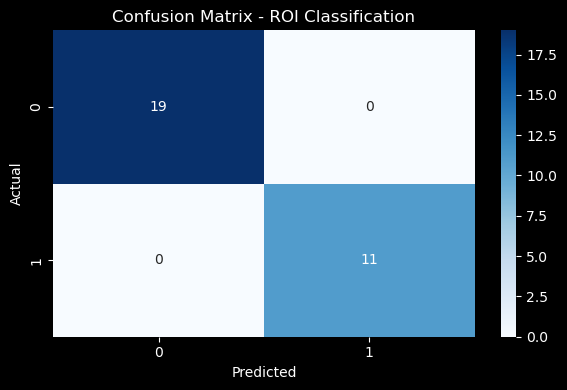

In [97]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - ROI Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [99]:
# Add predicted ROI to the main dataframe
df["Predicted_ROI (%)"] = reg.predict(X_reg)

# Define recommendation logic based on predicted ROI
def generate_recommendation(roi):
    if roi > 30:
        return "Highly Recommended"
    elif 10 < roi <= 30:
        return "Recommended"
    elif 0 < roi <= 10:
        return "Neutral - Reassess"
    else:
        return "Not Recommended"

# Apply logic to create 'Recommendation' column
df["Recommendation"] = df["Predicted_ROI (%)"].apply(generate_recommendation)


In [101]:
# Remove duplicates based on key columns
df_unique = df.drop_duplicates(subset=["Product_Name", "Category", "Channel", "Promotion_Type"])
columns_to_show = [
    "Product_ID", "Product_Name", "Category", "Channel", "Promotion_Type", "Predicted_ROI (%)", "Recommendation"
]

# Display a sample of the final output with context
df_unique[columns_to_show].head(20)

,Product_ID,Product_Name,Category,Channel,Promotion_Type,Predicted_ROI (%),Recommendation
0,1,Merci Assorted Chocolate 250g,Chocolate,Supermarket,Display Only,-57.3799,Not Recommended
1,1,Merci Assorted Chocolate 250g,Chocolate,Convenience Store,In-store Discount,-44.9833,Not Recommended
2,1,Merci Assorted Chocolate 250g,Chocolate,Supermarket,In-store Discount,43.7379,Highly Recommended
5,2,Werther's Original Caramels 150g,Candy,Supermarket,BOGO,50.7087,Highly Recommended
6,2,Werther's Original Caramels 150g,Candy,Convenience Store,BOGO,42.1785,Highly Recommended
7,2,Werther's Original Caramels 150g,Candy,Retail,Digital Campaign,17.6537,Recommended
8,2,Werther's Original Caramels 150g,Candy,Wholesale,Digital Campaign,-47.0946,Not Recommended
9,2,Werther's Original Caramels 150g,Candy,Convenience Store,Display Only,-12.1766,Not Recommended
10,3,Toffifee Caramel Hazelnut 125g,Chocolate,Convenience Store,In-store Discount,7.9696,Neutral - Reassess
11,3,Toffifee Caramel Hazelnut 125g,Chocolate,Supermarket,Digital Campaign,-4.2556,Not Recommended


In [103]:
df_unique.to_excel("final_recommendation.xlsx", index=False)